Ideal quantum well width: 3 nm
  n=1: 0.0418 eV
  n=2: 0.1671 eV
  n=3: 0.3760 eV
  Gap E2 - E1: 0.1253 eV


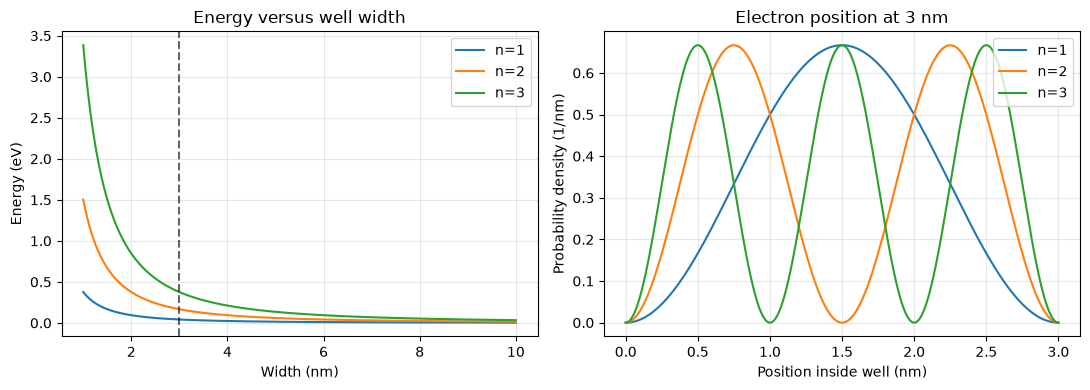

Saved plot to quantum_well.png


In [ ]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt

# Update to explore various nanoscale width
WIDTH_NM = 3.0
MIN_WIDTH_NM = 1.0
MAX_WIDTH_NM = 10.0

# Physical constants in SI units
PLANCK = 6.62607015e-34          # J s
ELECTRON_MASS = 9.1093837139e-31 # kg
ELEMENTARY_CHARGE = 1.602176634e-19  # J per eV


def energy_ev(level, width_nm):
    """Electron energy in an ideal 1D infinite well, in electronvolts."""
    width_m = np.asarray(width_nm) * 1e-9
    return (
        level**2 * PLANCK**2
        / (8 * ELECTRON_MASS * width_m**2 * ELEMENTARY_CHARGE)
    )


def probability_density(level, position_nm, width_nm):
    """Position probability density, in inverse nanometers."""
    return (
        (2 / width_nm)
        * np.sin(level * np.pi * position_nm / width_nm) ** 2
    )


def main():
    if not (MIN_WIDTH_NM <= WIDTH_NM <= MAX_WIDTH_NM):
        raise ValueError(
            "WIDTH_NM must be between MIN_WIDTH_NM and MAX_WIDTH_NM"
        )

    widths = np.linspace(MIN_WIDTH_NM, MAX_WIDTH_NM, 500)
    positions = np.linspace(0, WIDTH_NM, 500)

    print(f"Ideal quantum well width: {WIDTH_NM:g} nm")
    for level in (1, 2, 3):
        print(f"  n={level}: {energy_ev(level, WIDTH_NM):.4f} eV")

    gap = energy_ev(2, WIDTH_NM) - energy_ev(1, WIDTH_NM)
    print(f"  Gap E2 - E1: {gap:.4f} eV")

    fig, (ax_energy, ax_probability) = plt.subplots(
        1, 2, figsize=(11, 4)
    )

    for level in (1, 2, 3):
        ax_energy.plot(
            widths, energy_ev(level, widths), label=f"n={level}"
        )
        ax_probability.plot(
            positions,
            probability_density(level, positions, WIDTH_NM),
            label=f"n={level}",
        )

    ax_energy.axvline(
        WIDTH_NM, color="black", linestyle="--", alpha=0.6
    )
    ax_energy.set(
        title="Energy versus well width",
        xlabel="Width (nm)",
        ylabel="Energy (eV)",
    )
    ax_probability.set(
        title=f"Electron position at {WIDTH_NM:g} nm",
        xlabel="Position inside well (nm)",
        ylabel="Probability density (1/nm)",
    )

    for ax in (ax_energy, ax_probability):
        ax.grid(alpha=0.3)
        ax.legend()

    fig.tight_layout()
    fig.savefig("quantum_well.png", dpi=160)
    plt.show()
    print("Saved plot to quantum_well.png")


if __name__ == "__main__":
    main()